In [30]:
import os
import pandas as pd
import seaborn as sns
import kagglehub
import numpy as np
path=kagglehub.dataset_download('mlg-ulb/creditcardfraud')
print(os.listdir(path))
df=pd.read_csv(os.path.join(path,"creditcard.csv"))


['creditcard.csv']


In [31]:
print(df.head())
print(df.info())
print(df["Class"].unique().sum())


   Time        V1        V2        V3  ...       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  ...  0.133558 -0.021053  149.62      0
1   0.0  1.191857  0.266151  0.166480  ... -0.008983  0.014724    2.69      0
2   1.0 -1.358354 -1.340163  1.773209  ... -0.055353 -0.059752  378.66      0
3   1.0 -0.966272 -0.185226  1.792993  ...  0.062723  0.061458  123.50      0
4   2.0 -1.158233  0.877737  1.548718  ...  0.219422  0.215153   69.99      0

[5 rows x 31 columns]
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null 

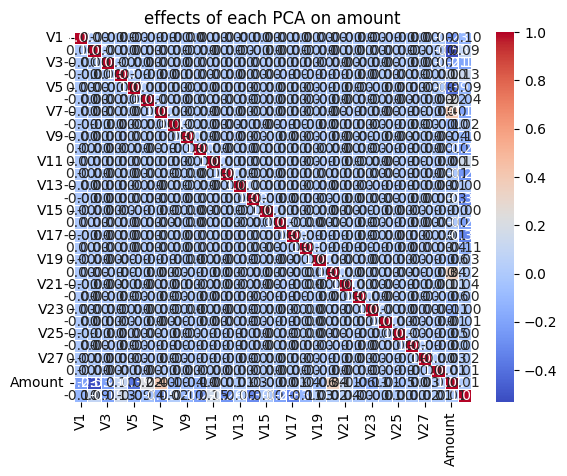

In [32]:
import matplotlib.pyplot as plt
df=df.drop(columns=["Time"])
raw_data=df.corr()
sns.heatmap(raw_data, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("effects of each PCA on amount")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

scaler = StandardScaler()

y = df["Class"]
X = df.drop(columns=["Class"])

preprocess = ColumnTransformer(
    transformers=[("scale_amount", scaler, ["Amount"])],
    remainder="passthrough",
)

model = RandomForestClassifier(n_estimators=1000, max_depth=int(28**0.5), random_state=42)

pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model),
])

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

pipeline.fit(x_train, y_train)
predictions = pipeline.predict(x_test)

print(classification_report(y_test, predictions))
print("Confusion matrix:\n", confusion_matrix(y_test, predictions))
